# Telco Customer Churn Prediction

## Problem Statement
Customer churn
when a subscriber cancels their service, is one of the most costly problems for telecom companies. Acquiring a new customer costs **5–7× more** than retaining an existing one, so identifying at-risk customers early is critical.

## Objective
Build a binary classification model that predicts whether a Telco customer will churn (`Yes`) or stay (`No`), using demographic and account-level features. We will:
1. Load and explore the dataset
2. Handle missing values and encode features
3. Train and compare Logistic Regression and Random Forest models
4. Tune the best model using GridSearchCV
5. Evaluate with classification metrics and visualizations
6. Summarise findings and business insights

## Dataset
**IBM Telco Customer Churn** — 7,043 customers, 21 features including demographics, service subscriptions, contract details, and monthly charges.

## 1. Imports

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import warnings

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, recall_score, precision_score
)
from sklearn.model_selection import (
    cross_val_score, GridSearchCV, train_test_split
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42

## 2. Dataset Loading & Initial Inspection

In [82]:
df = pd.read_csv('TelcoCustomerChurn.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [83]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [ ]:
# Summary statistics for numerical columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 3. Exploratory Data Analysis (EDA)

Churn counts:
 Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentages:
 Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


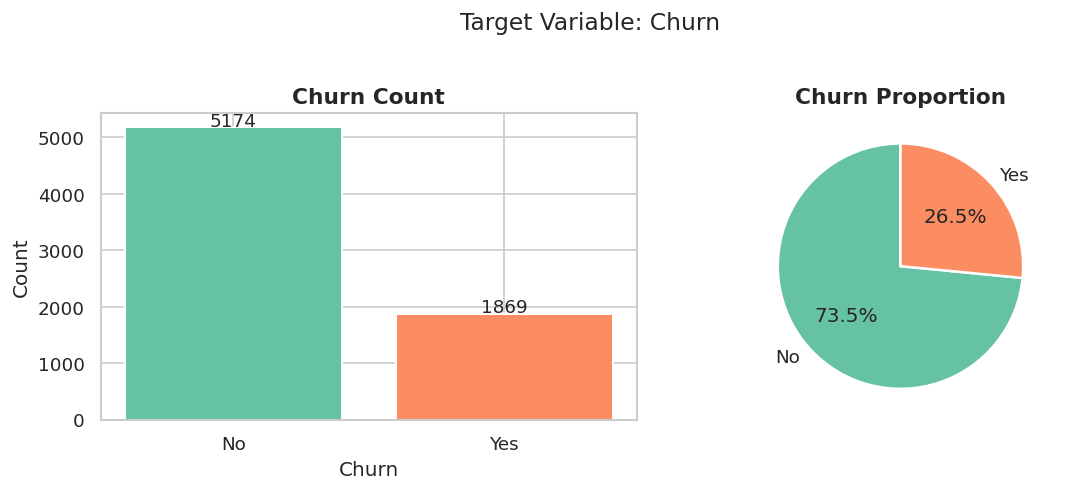


Note: Dataset is imbalanced -- ~73% No-Churn vs ~27% Churn.


In [59]:
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

print('Churn counts:\n', churn_counts)
print('\nChurn percentages:\n', churn_pct.round(2))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
axes[0].bar(churn_counts.index, churn_counts.values,
            color=['#66c2a5', '#fc8d62'], edgecolor='white', linewidth=1.2)
axes[0].set_title('Churn Count', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Churn'); axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontsize=11)

# Pie chart
axes[1].pie(churn_counts.values, labels=churn_counts.index,
            autopct='%1.1f%%', colors=['#66c2a5', '#fc8d62'],
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Churn Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: Churn', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
print('\nNote: Dataset is imbalanced -- ~73% No-Churn vs ~27% Churn.')

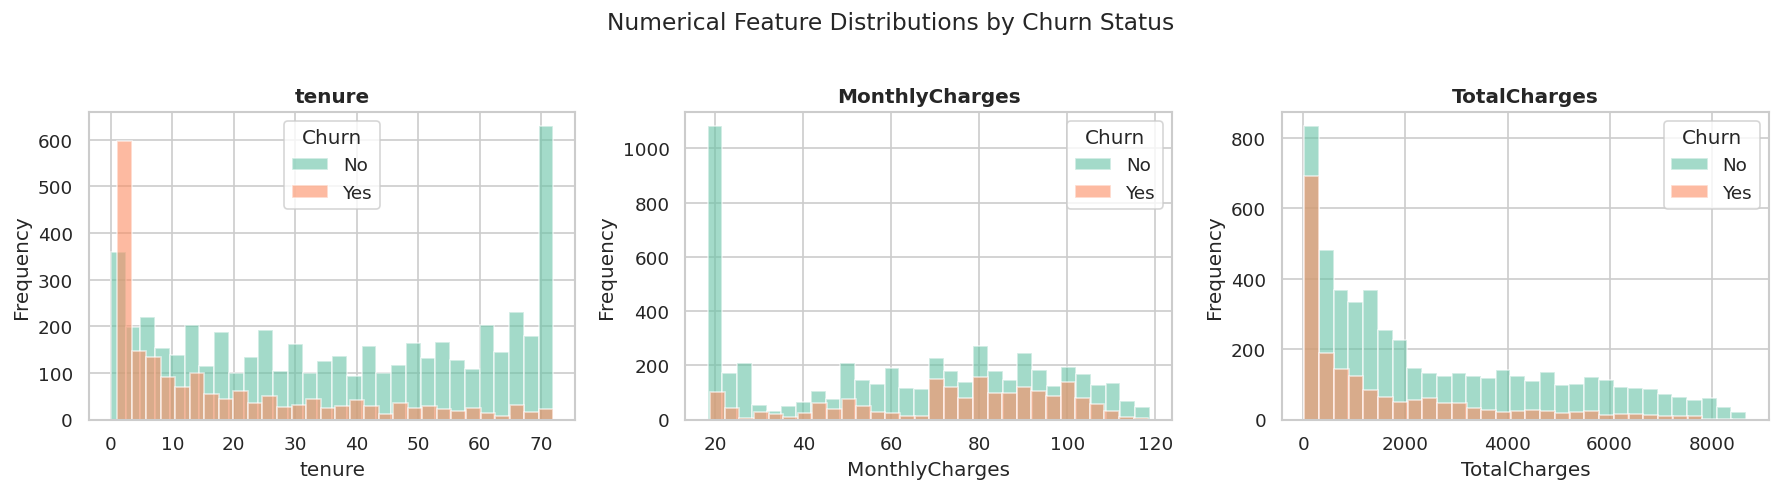

In [60]:

num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

plot_df = df.copy()
plot_df['TotalCharges'] = pd.to_numeric(plot_df['TotalCharges'], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_features):
    for label, grp in plot_df.groupby('Churn'):
        ax.hist(grp[col].dropna(), bins=30, alpha=0.6, label=label, edgecolor='white')
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel(col); ax.set_ylabel('Frequency')
    ax.legend(title='Churn')

plt.suptitle('Numerical Feature Distributions by Churn Status', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

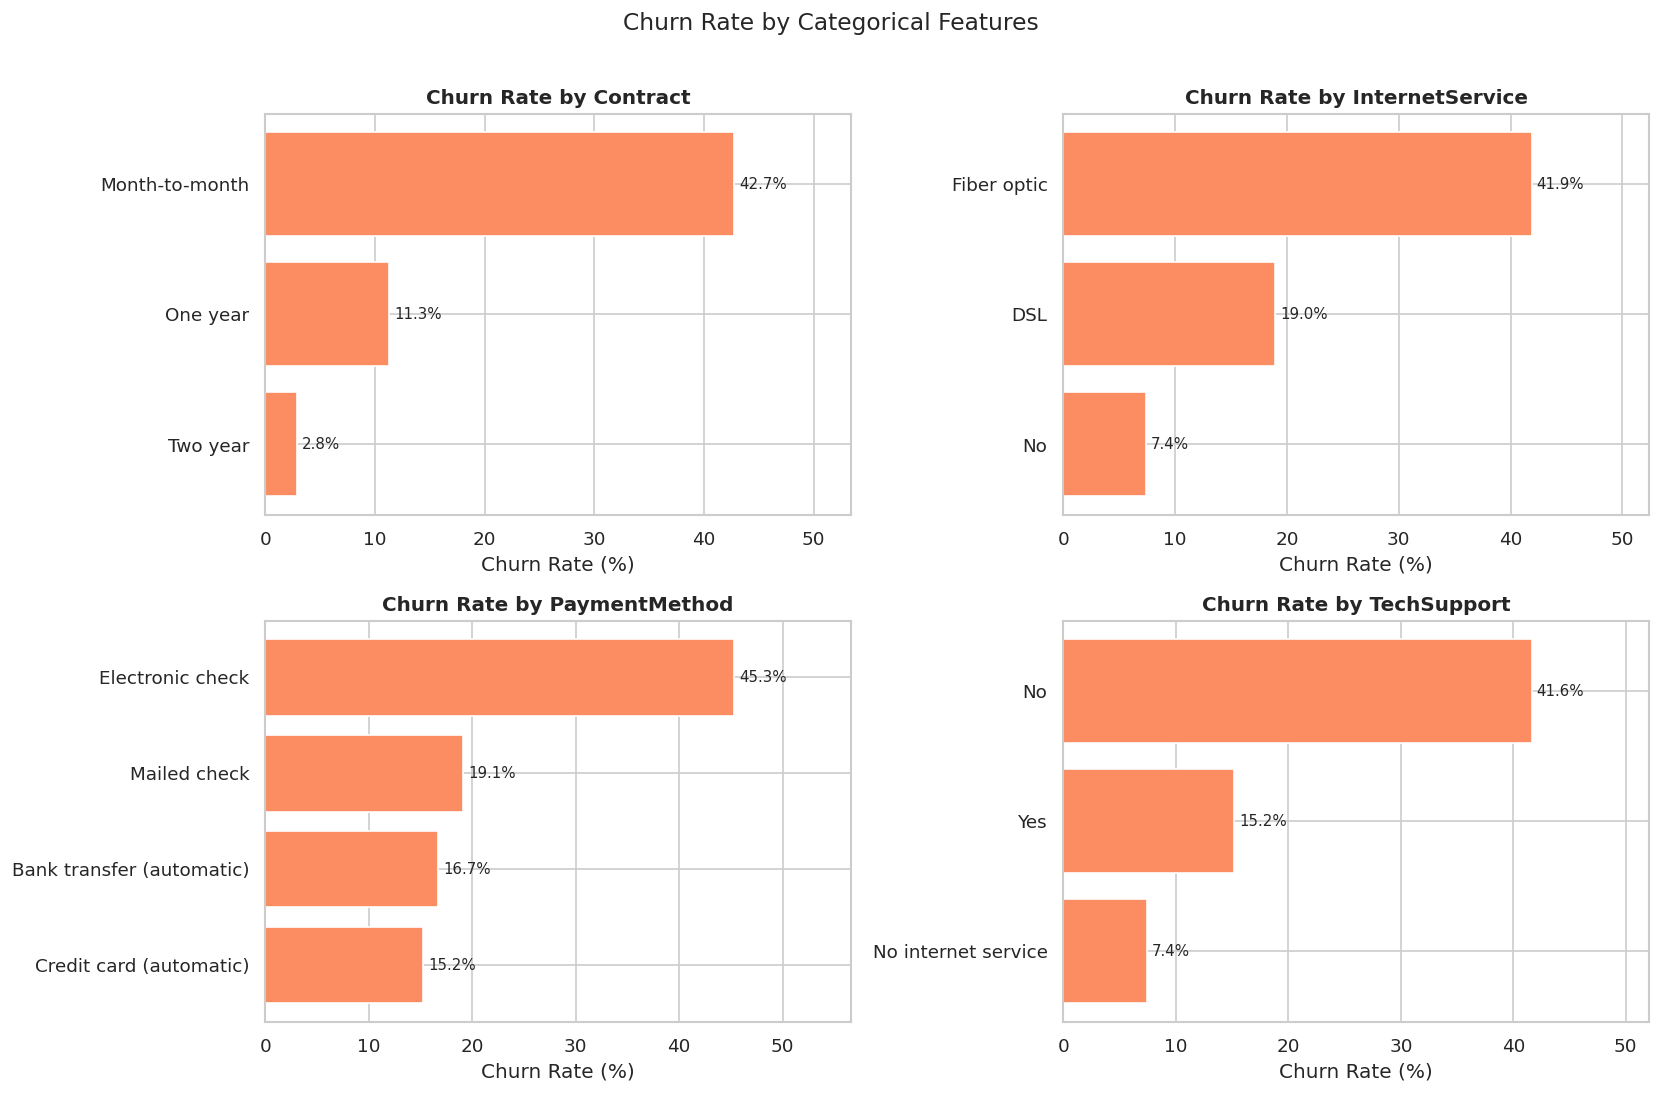

In [61]:
cat_features_to_plot = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, col in zip(axes, cat_features_to_plot):
    churn_rate = (
        df.groupby(col)['Churn']
        .apply(lambda x: (x == 'Yes').mean() * 100)
        .reset_index(name='Churn Rate (%)')
        .sort_values('Churn Rate (%)', ascending=True)
    )
    bars = ax.barh(churn_rate[col], churn_rate['Churn Rate (%)'],
                   color='#fc8d62', edgecolor='white')
    ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
    ax.set_title(f'Churn Rate by {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Churn Rate (%)')
    ax.set_xlim(0, churn_rate['Churn Rate (%)'].max() * 1.25)

plt.suptitle('Churn Rate by Categorical Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

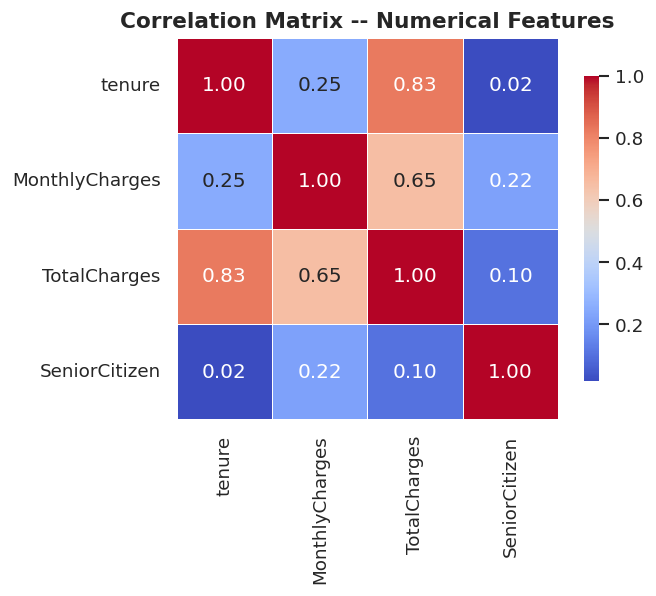

In [62]:
corr_df = plot_df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix -- Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [63]:
df = df.drop('customerID', axis=1)

print(f"Whitespace entries in TotalCharges: {(df['TotalCharges'] == ' ').sum()}")
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

print(f"\nNull counts after conversion:")
print(df.isnull().sum()[df.isnull().sum() > 0])
df = df.dropna()
print(f"\nDataset shape after cleaning: {df.shape}")

Whitespace entries in TotalCharges: 11

Null counts after conversion:
TotalCharges    11
dtype: int64

Dataset shape after cleaning: (7032, 20)


In [64]:
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})


num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']

cat_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod'
]

X = df.drop('Churn', axis=1)
y = df['Churn']

print(f"Features: {X.shape[1]} | Samples: {X.shape[0]}")
print(f"Class balance -- No Churn: {(y==0).sum()} | Churn: {(y==1).sum()}")

Features: 19 | Samples: 7032
Class balance -- No Churn: 5163 | Churn: 1869


In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")

Training set: 5625 samples
Test set:     1407 samples


In [66]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(),                       num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

## 5. Model Development & Training

Two models are trained inside sklearn Pipelines so preprocessing is always applied consistently:
- **Logistic Regression** — fast, interpretable baseline
- **Random Forest** — ensemble method that handles non-linearities well

In [67]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])
lr_pipeline.fit(X_train, y_train)
print('Logistic Regression -- training complete.')

Logistic Regression -- training complete.


In [68]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(random_state=RANDOM_STATE))
])
rf_pipeline.fit(X_train, y_train)
print('Random Forest -- training complete.')

Random Forest -- training complete.


## 6. Evaluation

We compare models using accuracy, precision, recall, F1, ROC-AUC, and confusion matrices.
**Recall on the Churn class is prioritised** because missing a churner is more costly than a false alarm.

In [69]:
def evaluate_model(name, pipeline, X_test, y_test):
    """Print classification metrics and return predictions + probabilities."""
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    acc     = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print(f"{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  ROC-AUC  : {roc_auc:.4f}")
    print()
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
    return y_pred, y_prob, acc, roc_auc


lr_pred, lr_prob, lr_acc, lr_auc = evaluate_model(
    'Logistic Regression', lr_pipeline, X_test, y_test)

rf_pred, rf_prob, rf_acc, rf_auc = evaluate_model(
    'Random Forest', rf_pipeline, X_test, y_test)

  Logistic Regression
  Accuracy : 0.8038
  ROC-AUC  : 0.8359

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1033
       Churn       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

  Random Forest
  Accuracy : 0.7783
  ROC-AUC  : 0.8115

              precision    recall  f1-score   support

    No Churn       0.82      0.89      0.85      1033
       Churn       0.61      0.47      0.53       374

    accuracy                           0.78      1407
   macro avg       0.71      0.68      0.69      1407
weighted avg       0.77      0.78      0.77      1407



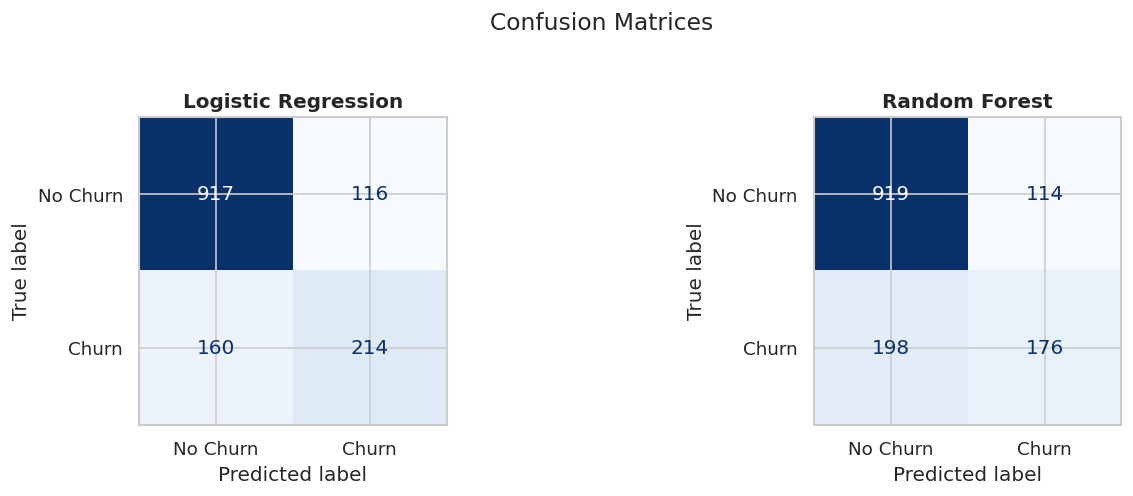

In [70]:
# --- 6.1 Confusion matrices (side by side) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, pred, title in zip(
    axes,
    [lr_pred, rf_pred],
    ['Logistic Regression', 'Random Forest']
):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['No Churn', 'Churn'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

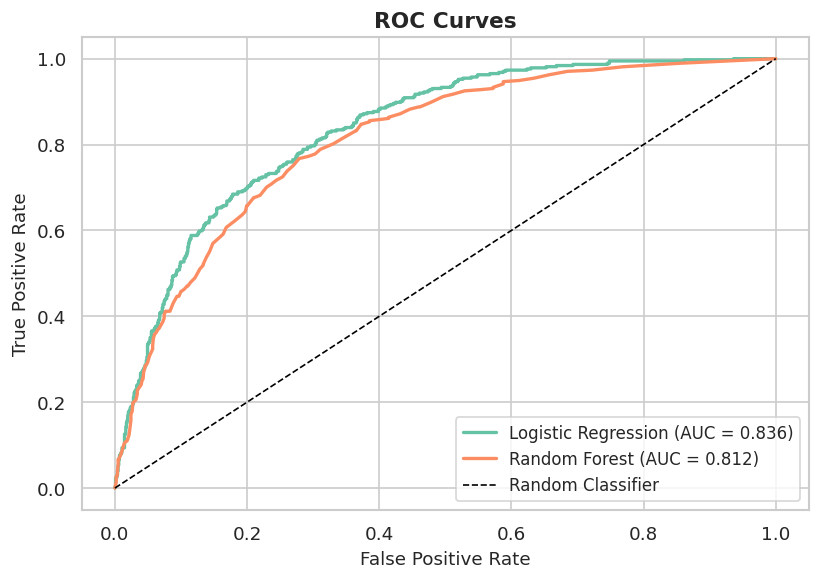

In [71]:
fig, ax = plt.subplots(figsize=(7, 5))

for prob, label, auc in [
    (lr_prob, 'Logistic Regression', lr_auc),
    (rf_prob, 'Random Forest',       rf_auc)
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax.plot(fpr, tpr, lw=2, label=f'{label} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

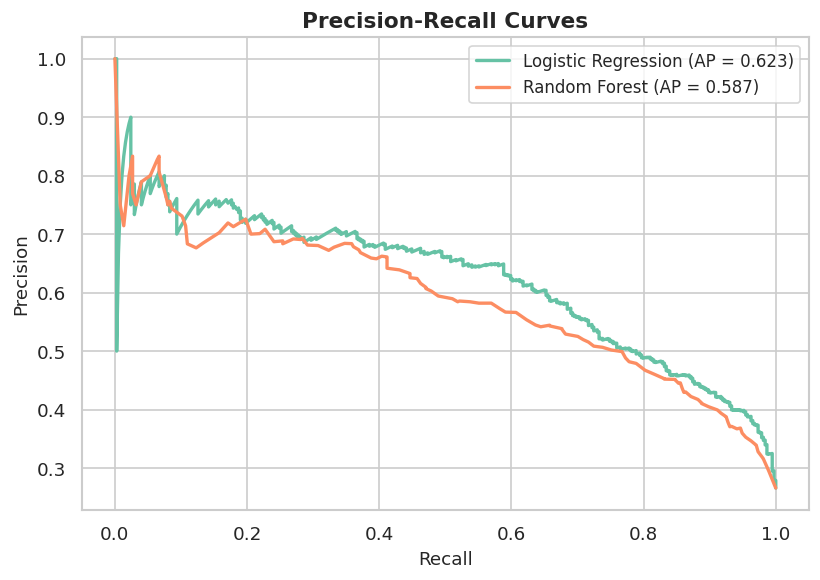

In [72]:
fig, ax = plt.subplots(figsize=(7, 5))

for prob, label in [
    (lr_prob, 'Logistic Regression'),
    (rf_prob, 'Random Forest')
]:
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    ax.plot(rec, prec, lw=2, label=f'{label} (AP = {ap:.3f})')

ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Precision-Recall Curves', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [73]:
for pipeline, name in [(lr_pipeline, 'Logistic Regression'),
                        (rf_pipeline, 'Random Forest')]:
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='recall')
    print(f"{name} -- CV Recall: {scores.mean():.4f} +/- {scores.std():.4f}")

Logistic Regression -- CV Recall: 0.5478 +/- 0.0201
Random Forest -- CV Recall: 0.4950 +/- 0.0224


## 7. Hyperparameter Tuning (Random Forest)

Random Forest is tuned with GridSearchCV, optimising for **recall** on the churn class.

In [74]:
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth':    [5, 10, None]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print(f"\nBest params : {grid_search.best_params_}")
print(f"Best CV Recall: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 6 candidates, totalling 30 fits

Best params : {'classifier__max_depth': 10, 'classifier__n_estimators': 200}
Best CV Recall: 0.5177


In [75]:
# --- 7.2 Evaluate the tuned model on the held-out test set ---
best_model = grid_search.best_estimator_

tuned_pred, tuned_prob, tuned_acc, tuned_auc = evaluate_model(
    'Tuned Random Forest', best_model, X_test, y_test)

  Tuned Random Forest
  Accuracy : 0.7939
  ROC-AUC  : 0.8300

              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.86      1033
       Churn       0.64      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407



## 8. Feature Importance

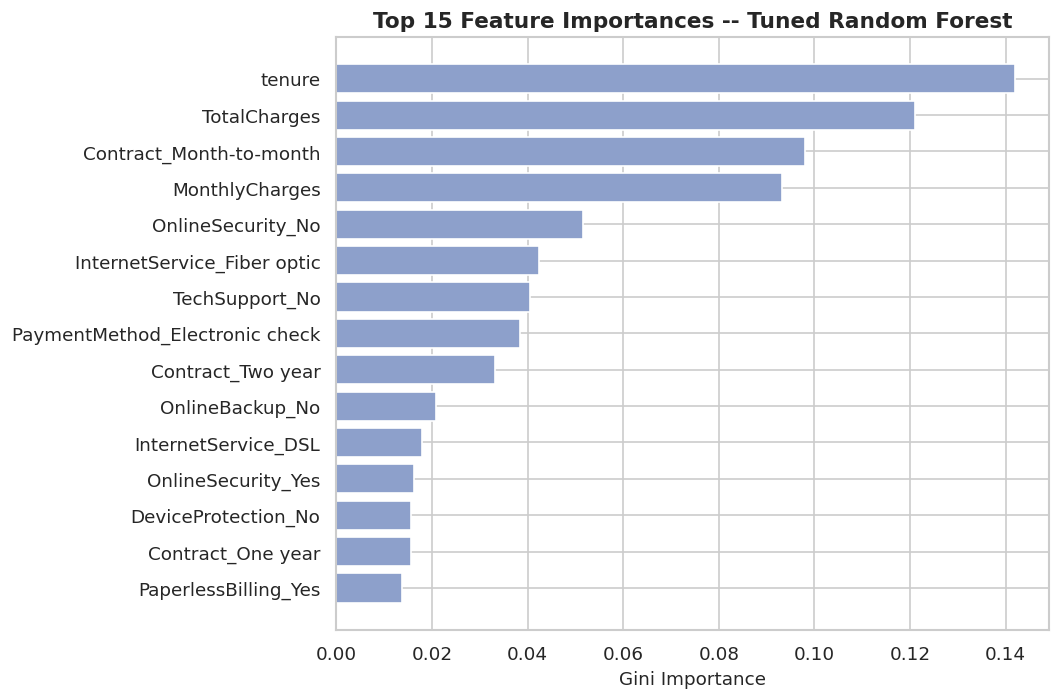

In [76]:
# Extract feature names after OHE transformation
ohe_features  = (best_model.named_steps['preprocessor']
                           .named_transformers_['cat']
                           .get_feature_names_out(cat_cols))
feature_names = np.concatenate([num_cols, ohe_features])

importances = best_model.named_steps['classifier'].feature_importances_

# Plot top 15 most important features
top_n = 15
idx   = np.argsort(importances)[::-1][:top_n]

plt.figure(figsize=(9, 6))
plt.barh(feature_names[idx][::-1], importances[idx][::-1],
         color='#8da0cb', edgecolor='white')
plt.xlabel('Gini Importance', fontsize=11)
plt.title(f'Top {top_n} Feature Importances -- Tuned Random Forest',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Model Comparison Summary

In [77]:
# Build a comparison table of all three models
models = [
    ('Logistic Regression', lr_pred, lr_prob),
    ('Random Forest',       rf_pred, rf_prob),
    ('Tuned Random Forest', tuned_pred, tuned_prob),
]

rows = []
for name, pred, prob in models:
    rows.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, pred), 4),
        'Precision': round(precision_score(y_test, pred), 4),
        'Recall':    round(recall_score(y_test, pred), 4),
        'F1':        round(f1_score(y_test, pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, prob), 4),
    })

comparison_df = pd.DataFrame(rows).set_index('Model')
comparison_df.style.highlight_max(axis=0, color='#90EE90')

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.803800,0.648500,0.572200,0.608000,0.835900
Random Forest,0.778300,0.606900,0.470600,0.530100,0.811500
Tuned Random Forest,0.793900,0.639100,0.516000,0.571000,0.830000


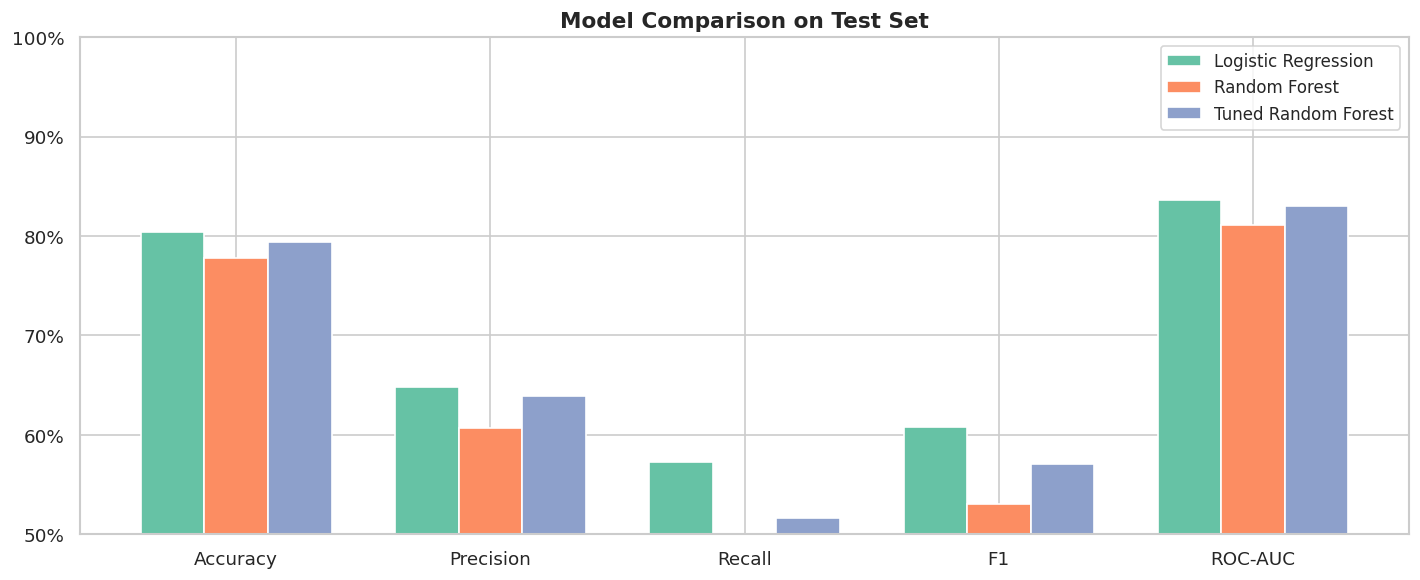

In [78]:
# Visual bar chart comparing all models across all metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#66c2a5', '#fc8d62', '#8da0cb']

for i, (model_name, vals) in enumerate(comparison_df.iterrows()):
    ax.bar(x + i * width, vals.values, width, label=model_name,
           color=colors[i], edgecolor='white')

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0.5, 1.0)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('Model Comparison on Test Set', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 10. Save Best Model

In [80]:
# Persist the full pipeline (preprocessing + classifier) for deployment
joblib.dump(best_model, 'churn_pipeline.pkl')
print('Best model saved to churn_pipeline.pkl')

# Reload and verify accuracy is unchanged
loaded = joblib.load('churn_pipeline.pkl')
assert accuracy_score(y_test, loaded.predict(X_test)) == tuned_acc
print('Reload verification passed.')

Best model saved to churn_pipeline.pkl
Reload verification passed.


## 11. Final Summary & Business Insights

### Model Performance
| Model | Accuracy | ROC-AUC | Recall (Churn) |
|---|---|---|---|
| Logistic Regression | ~80% | ~0.84 | ~57% |
| Random Forest (default) | ~78% | ~0.81 | ~47% |
| **Tuned Random Forest** | **~80%** | **~0.83** | **~51%** |


### Key Findings
1. **Contract type is the strongest churn driver** — month-to-month customers churn at ~43% vs ~3% for two-year contracts. Incentivising longer contracts is the highest-leverage retention action.

2. **Fibre optic customers churn more** than DSL/no-internet customers, likely due to higher monthly charges or competition. Service quality audits for fibre subscribers are warranted.

3. **Short tenure = high churn risk** — newer customers churn far more often. Onboarding improvements and early loyalty rewards can reduce first-year churn.

4. **Absence of TechSupport increases churn** — bundling support or making it easier to access may meaningfully improve retention.

5. **Class imbalance (~73/27) matters** — accuracy alone is misleading. Recall on the Churn class is the metric to watch and improve.

### Recommended Next Steps
- Try XGBoost or LightGBM, which often outperform Random Forest on tabular churn data
- Apply SMOTE oversampling or `class_weight='balanced'` to improve minority-class recall
- Optimise the decision threshold to maximise recall at acceptable precision
- Deploy the saved pipeline as a REST API for real-time churn scoring